# 05 Post-Processing — Mindestfläche, 10 GWh, 500 kWh/kW

**PA1 ZHAW IUNR** | Bächler, Hofstetter, Reichlin | Betreuer: Patrick Laube

Filtert die WLC-Eignungskarte nach den gesetzlichen Anforderungen (Art. 71a EnG):
1. Mindestfläche ≥ 10 ha zusammenhängend
2. Min. 10 GWh Jahresproduktion
3. Min. 500 kWh/kW Winterproduktion

**Input:**
```
outputs/suitability_wlc.tif              (WLC-Eignungskarte, kontinuierlich 0–1)
outputs/suitability_classes.tif          (5 Klassen)
data/processed/constraints/constraint_mask_s2.tif
```

**Output:**
```
outputs/suitability_postprocessed.tif    (gefiltert, 0 = entfernt)
outputs/top_sites.gpkg                   (Top-Standorte als Polygone)
outputs/tables/postprocessing_stats.csv
outputs/figures/postprocessing_map.png
```

## 1. Setup

In [16]:
from pathlib import Path
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import shapes
from scipy.ndimage import label
from shapely.geometry import shape
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

RAW = Path("../data/raw")
PROC = Path("../data/processed")
OUT_R = Path("../outputs")
OUT_F = OUT_R / "figures"
OUT_T = OUT_R / "tables"
for d in [OUT_F, OUT_T]:
    d.mkdir(parents=True, exist_ok=True)

CRS = "EPSG:2056"
RES = 25
NODATA = -9999.0
PX_AREA_M2 = RES * RES           # 625 m²
PX_AREA_HA = PX_AREA_M2 / 1e4    # 0.0625 ha
PX_AREA_KM2 = PX_AREA_M2 / 1e6   # 0.000625 km²

# Post-Processing Parameter (Art. 71a EnG, Swissolar 2025)
MIN_AREA_HA = 10           # Mindestfläche zusammenhängend
MIN_ANNUAL_GWH = 10        # Min. Jahresproduktion
MIN_WINTER_KWH_KW = 500   # Min. Winterproduktion pro kWp
ETA = 0.18                 # Systemeffizienz (konservativ, alpin)

print(f"Parameter: ≥{MIN_AREA_HA} ha | ≥{MIN_ANNUAL_GWH} GWh/a | ≥{MIN_WINTER_KWH_KW} kWh/kW Winter | η={ETA}")

Parameter: ≥10 ha | ≥10 GWh/a | ≥500 kWh/kW Winter | η=0.18


## 2. Daten laden

In [17]:
import json as _json
import re as _re

# WLC-Eignungskarte
suit_path = OUT_R / "suitability_wlc.tif"
with rasterio.open(suit_path) as src:
    suit = src.read(1)
    transform = src.transform
    profile = src.profile.copy()
    height, width = suit.shape

# Constraint-Maske
with rasterio.open(PROC / "constraints/constraint_mask_s2.tif") as src:
    mask = src.read(1)

valid = (suit > 0) & (mask == 1)

# CLASSES automatisch aus Notebook 04 laden — immer synchron, keine Doppeldefinition
_nb04_path = Path("04_wlc.ipynb")
with open(_nb04_path, encoding="utf-8") as _f:
    _nb04_json = _json.load(_f)

CLASSES = None
for _cell in _nb04_json["cells"]:
    _src = "".join(_cell["source"])
    if "CLASSES = {" in _src:
        _m = _re.search(r"(CLASSES\s*=\s*\{[^}]+\})", _src, _re.DOTALL)
        if _m:
            exec(_m.group(1))  # injiziert CLASSES in den Notebook-Scope
        break

if CLASSES is None:
    raise RuntimeError("CLASSES konnte nicht aus 04_wlc.ipynb geladen werden — Pfad prüfen")

# CLASS_COLORS: identisch zu NB04 plot_suitability() — dort lokale Variable, hier global
CLASS_COLORS = ["#313695", "#74add1", "#ffffbf", "#f46d43", "#a50026"]  # colorblind-safe
CLASS_LABELS  = [v[2] for v in CLASSES.values()]
cmap_cls   = mcolors.ListedColormap(CLASS_COLORS)
bounds_cls = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm_cls   = mcolors.BoundaryNorm(bounds_cls, cmap_cls.N)

def suit_to_class(arr, mask_2d):
    """Klassifiziert kontinuierliche Eignungswerte [0–1] in 5 diskrete Klassen (NaN = kein Wert)."""
    c = np.zeros(arr.shape, dtype=np.float32)
    m = mask_2d & (arr > 0)
    v = arr[m]
    cls = np.ones(v.shape)
    for cls_id, (lo, hi, _) in CLASSES.items():
        if cls_id > 1:
            cls[v >= lo] = cls_id
    c[m] = cls
    return np.where(m, c, np.nan)

def mean_suit_to_class(s):
    """Gibt die Klasse (1–5) für einen Eignungswert zurück."""
    for cls_id in sorted(CLASSES.keys(), reverse=True):
        lo, _, _ = CLASSES[cls_id]
        if s >= lo:
            return cls_id
    return min(CLASSES.keys())

print(f"WLC-Karte: {suit_path.name} | {width}×{height}")
print(f"Geeignete Pixel: {valid.sum():,} ({valid.sum() * PX_AREA_KM2:.0f} km²)")
print(f"Klassen aus NB04: { {k: v[2] for k, v in CLASSES.items()} }")


WLC-Karte: suitability_wlc.tif | 5641×4010
Geeignete Pixel: 626,229 (391 km²)
Klassen aus NB04: {1: 'Unsuitable or Low suitability', 2: 'Moderate suitability', 3: 'Suitable', 4: 'Well suited', 5: 'Very well suited'}


In [18]:
# Globalstrahlung (für 10 GWh Berechnung)
solar_path = PROC / "criteria/f01_globalstrahlung.tif"
with rasterio.open(solar_path) as src:
    f01_norm = src.read(1).astype(np.float32)

# Wintereinstrahlung (für 500 kWh/kW Berechnung)
winter_path = PROC / "criteria/f02_wintereinstrahlung.tif"
with rasterio.open(winter_path) as src:
    f02_norm = src.read(1).astype(np.float32)

# De-Normalisierung: normalisierte [0,1] Werte → absolute kWh-Werte
# Normalisierungsgrenzen aus 03_preprocessing_wlc.ipynb (Jahres-/Wintersumme bei 45° Neigung, GR)
# Formel aus normalize_linear(): x_norm = (x - min) / (max - min)  →  x_abs = x_norm * (max - min) + min
SOLAR_MIN,  SOLAR_MAX  = 169.0, 1787.0   # kWh/m²/a — Jahreseinstrahlung bei 45°
WINTER_MIN, WINTER_MAX =  41.0,  981.0   # kWh/m²   — Wintereinstrahlung (Okt–März) bei 45°

solar_abs  = f01_norm * (SOLAR_MAX  - SOLAR_MIN)  + SOLAR_MIN   # kWh/m²/a
winter_abs = f02_norm * (WINTER_MAX - WINTER_MIN) + WINTER_MIN  # kWh/m²

# Pixel ausserhalb Constraint-Maske auf NODATA setzen (werden in späteren Filtern ausgeschlossen)
solar_abs  = np.where(valid, solar_abs,  NODATA).astype(np.float32)
winter_abs = np.where(valid, winter_abs, NODATA).astype(np.float32)

print(f"Solar absolut:  {solar_abs[valid].min():.0f}–{solar_abs[valid].max():.0f} kWh/m²/a")
print(f"Winter absolut: {winter_abs[valid].min():.0f}–{winter_abs[valid].max():.0f} kWh/m²")


Solar absolut:  169–1787 kWh/m²/a
Winter absolut: 41–981 kWh/m²


## 3. Filter 1: Mindestfläche ≥ 10 ha

Zusammenhängende Flächen identifizieren und zu kleine entfernen.

Ref: Swissolar (2025) §4.1.1: Mind. 7 MW → 10–20 ha Nettofläche für 10 GWh.

In [19]:
# Zusammenhängende Flächen identifizieren
suit_binary = valid.astype(int)
labeled, n_clusters = label(suit_binary)
print(f"Zusammenhängende Flächen vor Filter: {n_clusters}")

# Fläche pro Cluster berechnen (vektorisiert mit bincount — deutlich schneller als Python-Loop)
counts = np.bincount(labeled.ravel())          # counts[i] = Pixelanzahl von Cluster i (Index 0 = Hintergrund)
areas_ha = counts * PX_AREA_HA                 # Fläche in ha pro Cluster

cluster_sizes = {
    i: {"pixels": int(counts[i]), "area_ha": float(areas_ha[i])}
    for i in range(1, n_clusters + 1)
}

# Filter: nur Cluster ≥ MIN_AREA_HA behalten (vektorisiert)
keep_ids = np.where(areas_ha[1:] >= MIN_AREA_HA)[0] + 1  # Cluster-IDs die den Filter bestehen (Offset +1 wegen Hintergrund)
mask_area = np.isin(labeled, keep_ids).astype(np.uint8)   # Boolean-Maske: 1 = behalten, 0 = entfernt
kept = len(keep_ids)
removed_area = n_clusters - kept

print(f"Nach Mindestfläche ≥ {MIN_AREA_HA} ha: {kept} Flächen behalten, {removed_area} entfernt")
print(f"Verbleibende Fläche: {mask_area.sum() * PX_AREA_KM2:.0f} km² ({mask_area.sum() * PX_AREA_HA:.0f} ha)")


Zusammenhängende Flächen vor Filter: 36998
Nach Mindestfläche ≥ 10 ha: 736 Flächen behalten, 36262 entfernt
Verbleibende Fläche: 213 km² (21316 ha)


## 4. Filter 2: Min. 10 GWh Jahresproduktion

Pro zusammenhängende Fläche: Fläche × mittlere Einstrahlung × η ≥ 10 GWh

Ref: Art. 71a Abs. 2 EnG. Frischholz et al. (2024): ~1400 kWh/kWp.

In [20]:
# Nur ausführen wenn absolute Einstrahlungswerte vorhanden
if solar_abs is not None:
    # Neu labeln nach Flächen-Filter
    labeled2, n2 = label(mask_area)
    mask_gwh = np.zeros_like(mask_area)
    
    gwh_stats = []
    for i in range(1, n2 + 1):
        cluster_mask = labeled2 == i
        px_count = cluster_mask.sum()
        area_m2 = px_count * PX_AREA_M2
        
        # Mittlere Einstrahlung auf dieser Fläche
        solar_vals = solar_abs[cluster_mask & (solar_abs != NODATA)]
        if solar_vals.size == 0:
            continue
        mean_irrad = solar_vals.mean()  # kWh/m²/a
        
        # Jahresproduktion: Fläche × Einstrahlung × η
        annual_kwh = area_m2 * mean_irrad * ETA
        annual_gwh = annual_kwh / 1e6
        
        gwh_stats.append({
            "cluster": i, "area_ha": px_count * PX_AREA_HA,
            "mean_irrad_kwh": mean_irrad, "annual_gwh": annual_gwh,
            "passes": annual_gwh >= MIN_ANNUAL_GWH
        })
        
        if annual_gwh >= MIN_ANNUAL_GWH:
            mask_gwh[cluster_mask] = 1
    
    df_gwh = pd.DataFrame(gwh_stats)
    passed = df_gwh["passes"].sum()
    print(f"Nach ≥ {MIN_ANNUAL_GWH} GWh/a: {passed}/{len(df_gwh)} Flächen bestanden")
    print(f"Verbleibende Fläche: {mask_gwh.sum() * PX_AREA_KM2:.0f} km²")
    if len(df_gwh):
        print(f"\nProduktionsrange: {df_gwh['annual_gwh'].min():.1f}–{df_gwh['annual_gwh'].max():.1f} GWh/a")
else:
    print("⚠ Übersprungen — keine absoluten Einstrahlungsdaten")
    mask_gwh = mask_area.copy()

KeyboardInterrupt: 

## 5. Filter 3: Min. 500 kWh/kW Winterproduktion

Pro zusammenhängende Fläche: mittlere Wintereinstrahlung × η ≥ 500 kWh/kWp

Ref: Art. 71a Abs. 2 EnG. Frischholz et al. (2024): ~50% Winteranteil alpin.

In [ ]:
if winter_abs is not None:
    labeled3, n3 = label(mask_gwh)
    mask_winter = np.zeros_like(mask_gwh)
    
    winter_stats = []
    for i in range(1, n3 + 1):
        cluster_mask = labeled3 == i
        
        winter_vals = winter_abs[cluster_mask & (winter_abs != NODATA)]
        if winter_vals.size == 0:
            continue
        mean_winter = winter_vals.mean()  # kWh/m² (Okt–März)
        
        # Winterproduktion pro kWp: Einstrahlung × η
        # BFE 75° Daten sind Jahreswerte bei 75° Neigung
        # Als Winter-Proxy: ~60% davon fallen in Okt–März (alpin)
        winter_kwh_kwp = mean_winter * ETA * 0.6 * 1000  # ×1000 weil kWp → m²
        
        winter_stats.append({
            "cluster": i, "area_ha": cluster_mask.sum() * PX_AREA_HA,
            "mean_winter_kwh": mean_winter,
            "winter_kwh_kwp": winter_kwh_kwp,
            "passes": winter_kwh_kwp >= MIN_WINTER_KWH_KW
        })
        
        if winter_kwh_kwp >= MIN_WINTER_KWH_KW:
            mask_winter[cluster_mask] = 1
    
    df_winter = pd.DataFrame(winter_stats)
    passed_w = df_winter["passes"].sum()
    print(f"Nach ≥ {MIN_WINTER_KWH_KW} kWh/kW Winter: {passed_w}/{len(df_winter)} Flächen bestanden")
    print(f"Verbleibende Fläche: {mask_winter.sum() * PX_AREA_KM2:.0f} km²")
else:
    print("⚠ Übersprungen — keine Wintereinstrahlungsdaten")
    mask_winter = mask_gwh.copy()

Nach ≥ 500 kWh/kW Winter: 736/736 Flächen bestanden
Verbleibende Fläche: 213 km²


## 6. Finale Eignungskarte & Top-Standorte

In [ ]:
# Finale Karte: WLC-Werte nur wo alle Filter bestanden
suit_final = np.where(mask_winter == 1, suit, 0).astype(np.float32)

# Speichern
final_path = OUT_R / "suitability_postprocessed.tif"
with rasterio.open(final_path, "w", **profile) as dst:
    dst.write(suit_final, 1)

print(f"Finale Karte: {final_path.name}")
print(f"Geeignete Pixel: {(suit_final > 0).sum():,} ({(suit_final > 0).sum() * PX_AREA_KM2:.0f} km²)")

Finale Karte: suitability_postprocessed.tif
Geeignete Pixel: 341,055 (213 km²)


In [ ]:
# Top-Standorte als GeoDataFrame extrahieren
labeled_final, n_final = label((suit_final > 0).astype(int))
print(f"Finale zusammenhängende Flächen: {n_final}")

sites = []
for i in range(1, n_final + 1):
    cmask = labeled_final == i
    px = cmask.sum()
    area_ha = px * PX_AREA_HA
    mean_suit = suit_final[cmask].mean()
    max_suit  = suit_final[cmask].max()

    # Schwerpunkt → LV95
    rows, cols = np.where(cmask)
    cy, cx = rows.mean(), cols.mean()
    ey = transform.f + cy * transform.e
    ex = transform.c + cx * transform.a

    # Jahresproduktion
    if solar_abs is not None:
        s_vals = solar_abs[cmask & (solar_abs != NODATA)]
        annual_gwh = (px * PX_AREA_M2 * s_vals.mean() * ETA / 1e6) if s_vals.size else 0
    else:
        annual_gwh = 0

    # Winterproduktion
    if winter_abs is not None:
        w_vals = winter_abs[cmask & (winter_abs != NODATA)]
        winter_gwh = (px * PX_AREA_M2 * w_vals.mean() * ETA / 1e6) if w_vals.size else 0
    else:
        winter_gwh = 0

    sites.append({
        "id": i, "area_ha": round(area_ha, 1), "area_km2": round(area_ha / 100, 2),
        "mean_suit": round(mean_suit, 3), "max_suit": round(max_suit, 3),
        "annual_gwh": round(annual_gwh, 1),
        "winter_gwh": round(winter_gwh, 1),
        "gwh_per_ha": round(annual_gwh / max(area_ha, 0.001), 3),
        "E_lv95": round(ex), "N_lv95": round(ey),
    })

df_sites = pd.DataFrame(sites).sort_values("mean_suit", ascending=False).reset_index(drop=True)
df_sites.index += 1
df_sites.index.name = "Rang"
print(f"\nTop-Standorte:")
df_sites.head(20)

Finale zusammenhängende Flächen: 736

Top-Standorte:


,id,area_ha,area_km2,mean_suit,max_suit,annual_gwh,winter_gwh,gwh_per_ha,E_lv95,N_lv95
Rang,,,,,,,,,,
1,398,31.4,0.31,0.868,0.911,97.3,51.3,3.100,2699860,1172804
2,155,18.3,0.18,0.864,0.897,55.8,30.1,3.049,2815841,1190370
3,554,27.1,0.27,0.859,0.900,78.9,38.5,2.917,2702282,1160412
4,90,10.1,0.10,0.858,0.889,29.7,15.8,2.935,2790256,1194831
5,426,39.2,0.39,0.855,0.896,117.0,60.2,2.986,2698052,1170645
6,550,44.2,0.44,0.855,0.901,132.0,66.4,2.983,2703119,1160571
7,394,66.5,0.66,0.855,0.910,198.8,101.3,2.990,2702116,1172724
8,209,54.6,0.55,0.853,0.895,165.1,88.2,3.027,2810073,1186270
9,147,103.5,1.03,0.851,0.898,316.6,170.0,3.059,2817138,1190483


In [ ]:
# Standorte als Polygone exportieren (GeoPackage)
from rasterio.features import shapes as rio_shapes
from shapely.geometry import shape as shp_shape

polygons = []
for geom, val in rio_shapes(labeled_final.astype(np.int32), mask=(labeled_final > 0), transform=transform):
    cid = int(val)
    site_row = df_sites[df_sites["id"] == cid]
    if site_row.empty:
        continue
    sr = site_row.iloc[0]
    polygons.append({
        "geometry": shp_shape(geom),
        "id": cid, "area_ha": sr["area_ha"], "mean_suit": sr["mean_suit"],
        "suit_class": mean_suit_to_class(sr["mean_suit"]),
        "annual_gwh": sr["annual_gwh"],
        "winter_gwh": sr["winter_gwh"],
        "gwh_per_ha": sr["gwh_per_ha"],
        "rang": site_row.index[0],
    })

if polygons:
    gdf_sites = gpd.GeoDataFrame(polygons, crs=CRS)
    sites_path = OUT_R / "top_sites.gpkg"
    gdf_sites.to_file(sites_path, driver="GPKG")
    print(f"Standort-Polygone: {sites_path} ({len(gdf_sites)} Features)")

Standort-Polygone: ..\outputs\top_sites.gpkg (736 Features)


## 7. Statistik-Export

In [ ]:
# CSV mit allen Standort-Infos
csv_path = OUT_T / "postprocessing_stats.csv"
df_sites.to_csv(csv_path)
print(f"Statistiken: {csv_path}")

# Zusammenfassung
print(f"\n{'='*50}")
print(f"POST-PROCESSING ZUSAMMENFASSUNG")
print(f"{'='*50}")
print(f"Vor Post-Processing:    {valid.sum() * PX_AREA_KM2:>6.0f} km²")
print(f"Nach ≥{MIN_AREA_HA} ha:            {mask_area.sum() * PX_AREA_KM2:>6.0f} km²")
if solar_abs is not None:
    print(f"Nach ≥{MIN_ANNUAL_GWH} GWh/a:          {mask_gwh.sum() * PX_AREA_KM2:>6.0f} km²")
if winter_abs is not None:
    print(f"Nach ≥{MIN_WINTER_KWH_KW} kWh/kW:        {mask_winter.sum() * PX_AREA_KM2:>6.0f} km²")
print(f"Finale Standorte:       {n_final}")
print(f"Totale geeignete Fläche:{(suit_final > 0).sum() * PX_AREA_KM2:>6.0f} km²")
if len(df_sites):
    print(f"Geschätzte Produktion:  {df_sites['annual_gwh'].sum():>6.0f} GWh/a")
print(f"{'='*50}")

Statistiken: ..\outputs\tables\postprocessing_stats.csv

POST-PROCESSING ZUSAMMENFASSUNG
Vor Post-Processing:       391 km²
Nach ≥10 ha:               213 km²
Nach ≥10 GWh/a:             213 km²
Nach ≥500 kWh/kW:           213 km²
Finale Standorte:       736
Totale geeignete Fläche:   213 km²
Geschätzte Produktion:   60032 GWh/a


## 8. Visualisierung

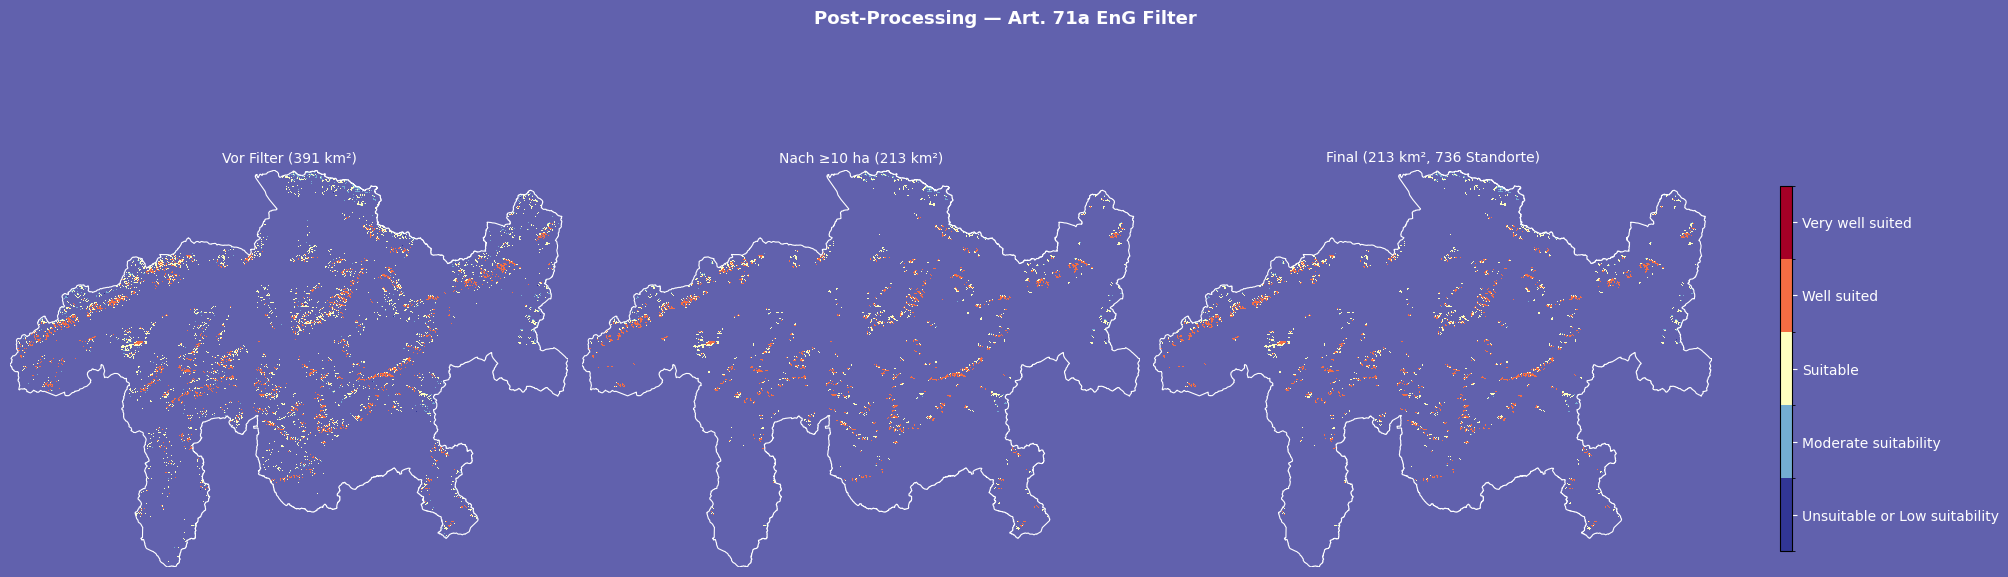

In [ ]:
BG_COLOR = "#6161AD"

# Kantonsgrenze direkt laden (kein Filter-Overhead)
gr_border = gpd.read_file(RAW / "swissboundaries/graubuenden_kantonsgrenze.shp").to_crs(CRS)

extent = [transform.c, transform.c + width * transform.a,
          transform.f + height * transform.e, transform.f]

# Klassifizierte Arrays für alle drei Panels
cls_before = suit_to_class(suit, valid)
cls_area   = suit_to_class(suit, mask_area.astype(bool))
cls_final  = suit_to_class(suit_final, (suit_final > 0))

fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True,
                         facecolor=BG_COLOR)
fig.suptitle("Post-Processing — Art. 71a EnG Filter", fontsize=13, fontweight="bold",
             color="white")

titles = [
    f"Vor Filter ({valid.sum() * PX_AREA_KM2:.0f} km²)",
    f"Nach ≥{MIN_AREA_HA} ha ({mask_area.sum() * PX_AREA_KM2:.0f} km²)",
    f"Final ({(suit_final > 0).sum() * PX_AREA_KM2:.0f} km², {n_final} Standorte)",
]
arrays = [cls_before, cls_area, cls_final]

for ax, arr, title in zip(axes, arrays, titles):
    ax.set_facecolor(BG_COLOR)
    ax.imshow(arr, cmap=cmap_cls, norm=norm_cls, aspect="equal",
              extent=extent, interpolation="nearest")
    gr_border.boundary.plot(ax=ax, color="white", linewidth=0.8)
    ax.set_title(title, fontsize=10, color="white")
    ax.set_axis_off()

# Gemeinsame Legende
sm = plt.cm.ScalarMappable(cmap=cmap_cls, norm=norm_cls)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.55, pad=0.04, aspect=30)
cbar.set_ticks([1, 2, 3, 4, 5])
cbar.set_ticklabels(CLASS_LABELS)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

fig.savefig(OUT_F / "postprocessing_map.png", dpi=150, bbox_inches="tight",
            facecolor=BG_COLOR)


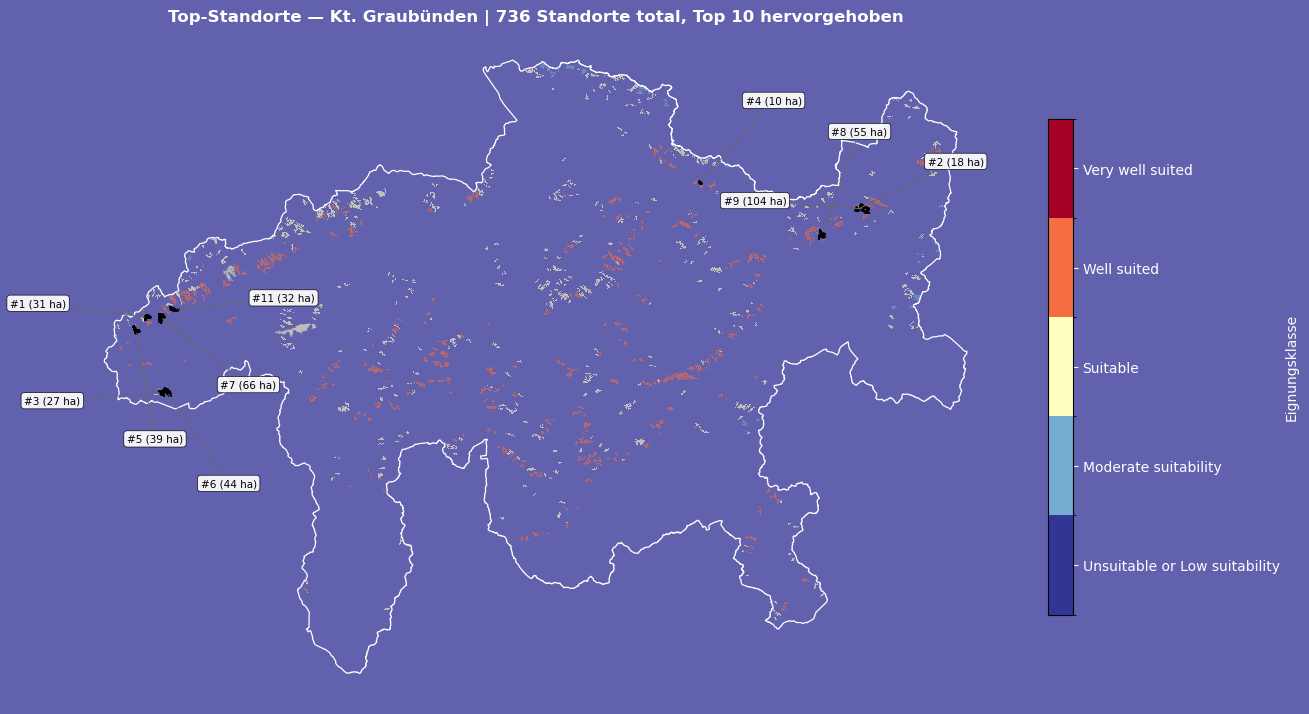

In [ ]:
# Top-10 Standorte Karte — Klassen-Farbschema, saubere Beschriftung
if "gdf_sites" in dir() and not gdf_sites.empty:
    fig, ax = plt.subplots(figsize=(13, 10), constrained_layout=True,
                           facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    gr_border.boundary.plot(ax=ax, color="white", linewidth=0.9)

    top10 = gdf_sites.nlargest(10, "mean_suit")

    # Alle Standorte (leicht transparent), Top-10 dicker
    gdf_sites.plot(ax=ax, column="suit_class", cmap=cmap_cls, norm=norm_cls,
                   alpha=0.6, edgecolor="none", linewidth=0)
    top10.plot(ax=ax, column="suit_class", cmap=cmap_cls, norm=norm_cls,
               alpha=1.0, edgecolor="black", linewidth=1.2)

    # Legende
    sm = plt.cm.ScalarMappable(cmap=cmap_cls, norm=norm_cls)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.04, fraction=0.03)
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.set_ticklabels(CLASS_LABELS)
    cbar.set_label("Eignungsklasse", color="white")
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    map_cx = (xlims[0] + xlims[1]) / 2
    map_cy = (ylims[0] + ylims[1]) / 2
    LABEL_DIST = 18_000   # Startabstand in m
    MIN_SEP    = 14_000   # Mindestabstand zwischen zwei Labels in m

    placed = []  # (ox, oy) — bereits platzierten Label-Positionen

    for _, r in top10.sort_values("rang").iterrows():
        c = r.geometry.centroid
        cx, cy = c.x, c.y

        # Ausgangswinkel: vom Kartenmittelpunkt weg
        import math
        base_angle = math.atan2(cy - map_cy, cx - map_cx)

        # Iterativ Winkel drehen bis freie Position gefunden
        dist = LABEL_DIST
        best_ox, best_oy = None, None
        for step in range(24):                       # 24 × 15° = voller Kreis
            angle = base_angle + step * math.pi / 12
            ox = cx + math.cos(angle) * dist
            oy = cy + math.sin(angle) * dist
            if all(math.hypot(ox - px, oy - py) >= MIN_SEP for px, py in placed):
                best_ox, best_oy = ox, oy
                break
            # Nach einem vollen Kreis den Radius vergrössern und nochmal versuchen
            if step == 23:
                dist += 8_000
                for step2 in range(24):
                    angle = base_angle + step2 * math.pi / 12
                    ox = cx + math.cos(angle) * dist
                    oy = cy + math.sin(angle) * dist
                    if all(math.hypot(ox - px, oy - py) >= MIN_SEP for px, py in placed):
                        best_ox, best_oy = ox, oy
                        break
                if best_ox is None:
                    best_ox, best_oy = cx + math.cos(base_angle) * dist, cy + math.sin(base_angle) * dist

        placed.append((best_ox, best_oy))
        ax.annotate(
            f"#{r['rang']} ({r['area_ha']:.0f} ha)",
            xy=(cx, cy), xytext=(best_ox, best_oy),
            fontsize=7.5, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.92, lw=0.5),
            arrowprops=dict(arrowstyle="-", color="dimgray", lw=0.7),
        )

    ax.set_title(
        f"Top-Standorte — Kt. Graubünden | {n_final} Standorte total, Top 10 hervorgehoben",
        fontweight="bold", color="white"
    )
    ax.set_axis_off()
    fig.savefig(OUT_F / "top_sites_map.png", dpi=150, bbox_inches="tight",
                facecolor=BG_COLOR)


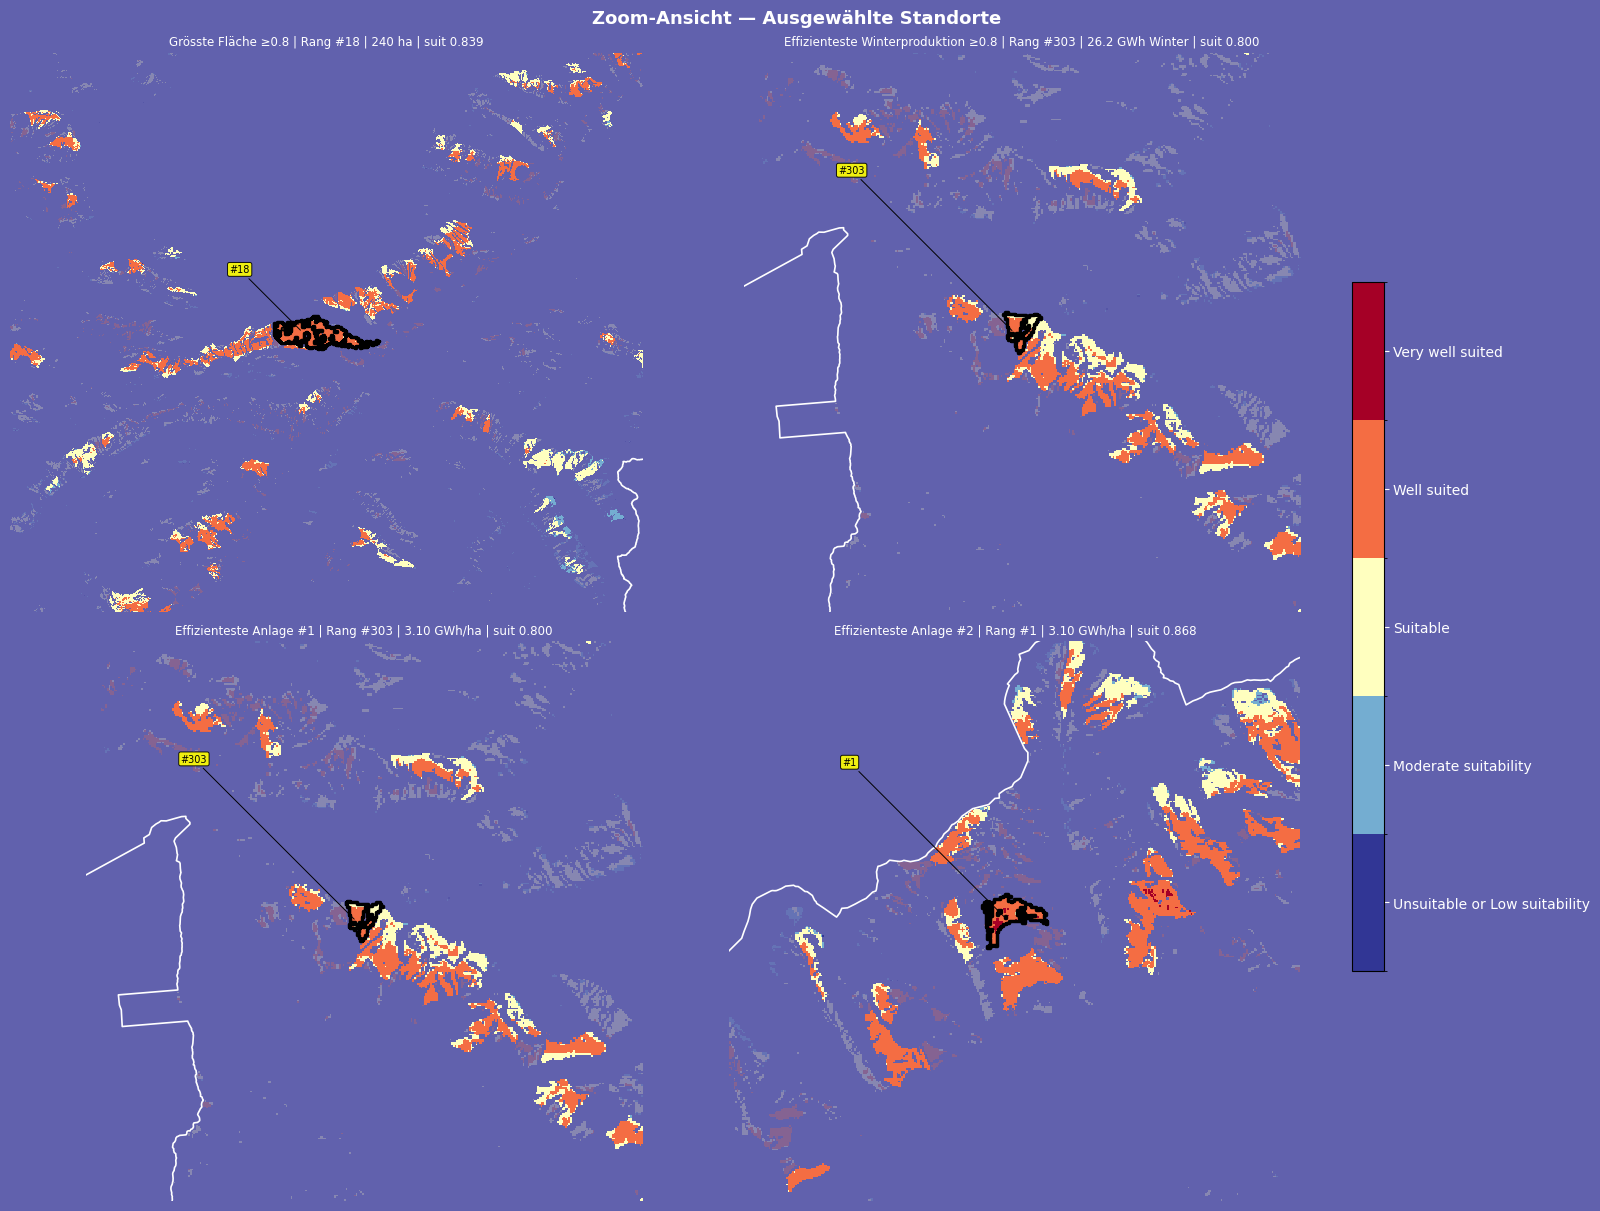

Gespeichert: ..\outputs\figures\zoom_sites.png


In [ ]:
# ── Zoom-Panels: Ausgewählte Standorte im Detail ─────────────────────────
if "gdf_sites" not in dir() or gdf_sites.empty or "cls_before" not in dir():
    print("Bitte erst Zellen 15–20 ausführen")
else:
    from shapely.geometry import box as _box
    from IPython.display import Image, display

    # Gemeindegrenzen laden (nur GR)
    _muni_all = gpd.read_file(RAW / "swissboundaries/swissboundaries_gemeinden.shp").to_crs(CRS)
    _canton_col = next(c for c in _muni_all.columns if "KANT" in c.upper() or c.upper().startswith("KT"))
    gr_muni = _muni_all[_muni_all[_canton_col].astype(str).str.contains("GR", case=False, na=False)].copy()
    _name_col = next((c for c in gr_muni.columns if c.upper() in ("NAME", "GEMEINDENA", "GMDNAME", "GDENAME")), None)

    hi = gdf_sites[gdf_sites["mean_suit"] >= 0.8].copy()
    if hi.empty:
        hi = gdf_sites.copy()

    # 1. Grösste Fläche mit mean_suit ≥ 0.8
    site_area = hi.loc[hi["area_ha"].idxmax()]

    # 2. Effizienteste Winterproduktion mit mean_suit ≥ 0.8 (Winter-GWh pro ha)
    w_col = "winter_gwh" if "winter_gwh" in gdf_sites.columns else "annual_gwh"
    hi = hi.copy()
    hi["_winter_eff"] = hi[w_col] / hi["area_ha"].clip(lower=0.001)
    site_winter = hi.loc[hi["_winter_eff"].idxmax()]

    # 3+4. Effizienteste 2 Anlagen (GWh/ha)
    e_col = "gwh_per_ha" if "gwh_per_ha" in gdf_sites.columns else "annual_gwh"
    eff2 = gdf_sites.nlargest(2, e_col)

    def _w_label(s):
        if "winter_gwh" in s.index:
            return f"{s['winter_gwh']:.1f} GWh Winter"
        return f"{s['annual_gwh']:.1f} GWh Jahres"

    def _e_label(s):
        if "gwh_per_ha" in s.index:
            return f"{s['gwh_per_ha']:.2f} GWh/ha"
        return f"{s['annual_gwh']:.1f} GWh"

    zoom_items = []
    seen_ids = set()

    def _add_zoom_item(site, title):
        sid = int(site['id']) if 'id' in site else int(site['rang'])
        if sid in seen_ids:
            return
        seen_ids.add(sid)
        zoom_items.append((site, title))

    _add_zoom_item(site_area,    f"Grösste Fläche ≥0.8 | Rang #{site_area['rang']} | "
                   f"{site_area['area_ha']:.0f} ha | suit {site_area['mean_suit']:.3f}")
    _add_zoom_item(site_winter,  f"Effizienteste Winterproduktion ≥0.8 | Rang #{site_winter['rang']} | "
                   f"{_w_label(site_winter)} | suit {site_winter['mean_suit']:.3f}")

    for idx, row in eff2.iterrows():
        _add_zoom_item(row, f"Effizienteste Anlage #{len(zoom_items)+1} | Rang #{row['rang']} | "
                         f"{_e_label(row)} | suit {row['mean_suit']:.3f}")

    # Falls noch nicht 4 eindeutige Standorte vorhanden sind, ergänzen
    if len(zoom_items) < 4:
        for _, row in gdf_sites.sort_values('mean_suit', ascending=False).iterrows():
            if len(zoom_items) >= 4:
                break
            if int(row['id']) in seen_ids:
                continue
            _add_zoom_item(row, f"Ergänzende Top-Anlage | Rang #{row['rang']} | "
                             f"{row['area_ha']:.0f} ha | suit {row['mean_suit']:.3f}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True,
                             facecolor=BG_COLOR)
    fig.suptitle("Zoom-Ansicht — Ausgewählte Standorte", fontsize=13, fontweight="bold",
                 color="white")

    for ax, (site, title) in zip(axes.flat, zoom_items):
        geom = site.geometry
        bx   = geom.bounds
        size = max(bx[2] - bx[0], bx[3] - bx[1])
        buf  = max(size * 2.5, 4_000)

        xlim = (bx[0] - buf, bx[2] + buf)
        ylim = (bx[1] - buf, bx[3] + buf)

        ax.set_facecolor(BG_COLOR)
        ax.imshow(cls_before, cmap=cmap_cls, norm=norm_cls, alpha=0.25,
                  aspect="equal", extent=extent, interpolation="nearest")
        ax.imshow(cls_final, cmap=cmap_cls, norm=norm_cls, alpha=1.0,
                  aspect="equal", extent=extent, interpolation="nearest")

        # Kantonsgrenze
        gr_border.boundary.plot(ax=ax, color="white", linewidth=1.2)

        # Gemeindegrenzen (nur sichtbare im Ausschnitt)
        _view_box = _box(xlim[0], ylim[0], xlim[1], ylim[1])
        _muni_vis = gr_muni[gr_muni.geometry.intersects(_view_box)].copy()
        if not _muni_vis.empty:
            _muni_vis.boundary.plot(ax=ax, color="white", linewidth=0.4, linestyle="--", alpha=0.6)

            # Gemeindenamen — grösste Gemeinden zuerst, Überlappungsschutz per Mindestabstand
            if _name_col:
                _min_sep = (xlim[1] - xlim[0]) * 0.15  # 15 % der Kartenbreite
                _placed = []  # bereits gesetzte Label-Positionen
                _muni_vis["_area"] = _muni_vis.geometry.area
                for _, row in _muni_vis.sort_values("_area", ascending=False).iterrows():
                    c = row.geometry.centroid
                    if not (xlim[0] < c.x < xlim[1] and ylim[0] < c.y < ylim[1]):
                        continue
                    # Abstand zu allen bereits platzierten Labels prüfen
                    if any(((c.x - px)**2 + (c.y - py)**2) ** 0.5 < _min_sep
                           for px, py in _placed):
                        continue
                    ax.text(c.x, c.y, row[_name_col], fontsize=6, ha="center", va="center",
                            color="white", alpha=0.9,
                            bbox=dict(boxstyle="round,pad=0.2", fc=BG_COLOR, alpha=0.6, lw=0))
                    _placed.append((c.x, c.y))

        # Standort hervorheben
        gpd.GeoDataFrame({"geometry": [geom]}, crs=CRS).plot(
            ax=ax, facecolor="none", edgecolor="black", linewidth=2.5, zorder=5
        )
        label = f"#{site['rang']}"
        status_text = site.get('status', None)
        if pd.notna(status_text):
            label += f"\n{status_text}"
        point = geom.representative_point()
        label_dx = max(2500, (bx[2] - bx[0]) * 0.35)
        label_dy = max(2500, (bx[3] - bx[1]) * 0.35)
        label_x = point.x + label_dx if point.x >= (bx[0] + bx[2]) / 2 else point.x - label_dx
        label_y = point.y + label_dy if point.y >= (bx[1] + bx[3]) / 2 else point.y - label_dy
        ax.annotate(
            label,
            xy=(point.x, point.y), xytext=(label_x, label_y),
            fontsize=7, ha='center', va='center',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.9, lw=0.7),
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7),
            zorder=6
        )

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(title, fontsize=8.5, pad=5, color="white")
        ax.set_axis_off()

    # Gemeinsame Legende
    sm = plt.cm.ScalarMappable(cmap=cmap_cls, norm=norm_cls)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.04, aspect=22, location="right")
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.set_ticklabels(CLASS_LABELS)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    saved_path = OUT_F / "zoom_sites.png"
    fig.savefig(saved_path, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    display(Image(filename=saved_path))
    print(f"Gespeichert: {saved_path}")


## 2.1 Constraint-Maske: Zoom auf Madrisasolar

Validation-Polygone: 34


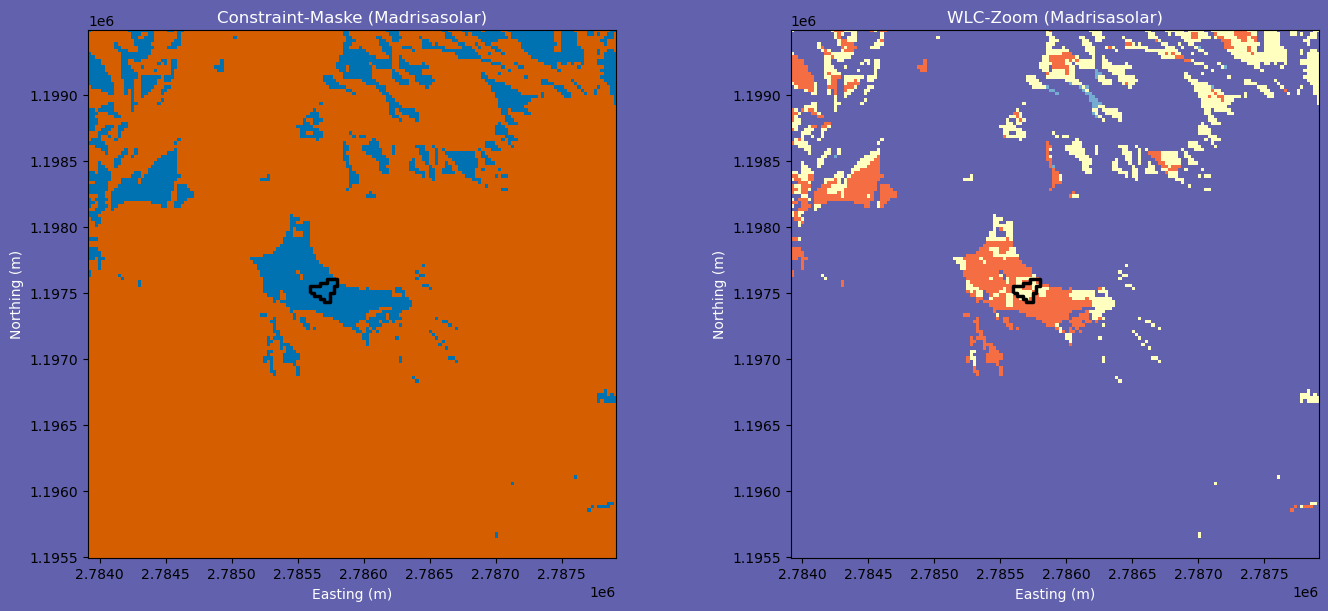

In [ ]:
# Lade Validierungsdaten und Madrisasolar-Standorte
plants_path = RAW / "validation" / "alpine_pv_plants.csv"
gdf_plants = gpd.read_file(plants_path) if plants_path.suffix != '.csv' else None
if gdf_plants is None:
    df_plants = pd.read_csv(plants_path)
    gdf_plants = gpd.GeoDataFrame(
        df_plants,
        geometry=gpd.points_from_xy(df_plants['lon'], df_plants['lat']),
        crs='EPSG:4326'
    ).to_crs(CRS)

# Validation raster → Polygon
from pathlib import Path
if 'RAW' not in globals():
    RAW = Path('../data/raw')
if 'PROC' not in globals():
    PROC = Path('../data/processed')
if 'OUT_R' not in globals():
    OUT_R = Path('../outputs')
if 'OUT_F' not in globals():
    OUT_F = OUT_R / 'figures'
if 'OUT_T' not in globals():
    OUT_T = OUT_R / 'tables'
if 'CRS' not in globals():
    CRS = 'EPSG:2056'
if 'BG_COLOR' not in globals():
    BG_COLOR = '#6161AD'

def _bootstrap_validation_dependencies():
    import json as _json
    import re as _re

    if 'np' not in globals():
        import numpy as np
        globals()['np'] = np
    if 'pd' not in globals():
        import pandas as pd
        globals()['pd'] = pd
    if 'gpd' not in globals():
        import geopandas as gpd
        globals()['gpd'] = gpd
    if 'rasterio' not in globals():
        import rasterio
        globals()['rasterio'] = rasterio
    if 'shapes' not in globals():
        from rasterio.features import shapes
        globals()['shapes'] = shapes
    if 'shape' not in globals():
        from shapely.geometry import shape
        globals()['shape'] = shape
    if 'mcolors' not in globals():
        import matplotlib.colors as mcolors
        globals()['mcolors'] = mcolors

    if 'suit' not in globals():
        suit_path = OUT_R / 'suitability_wlc.tif'
        with rasterio.open(suit_path) as src:
            globals()['suit'] = src.read(1)
            globals()['transform'] = src.transform
            globals()['profile'] = src.profile.copy()
            globals()['height'], globals()['width'] = globals()['suit'].shape
    if 'mask' not in globals():
        with rasterio.open(PROC / 'constraints/constraint_mask_s2.tif') as src:
            globals()['mask'] = src.read(1)
    if 'valid' not in globals():
        globals()['valid'] = (globals()['suit'] > 0) & (globals()['mask'] == 1)

    if 'CLASSES' not in globals():
        _nb04_path = Path('04_wlc.ipynb')
        with open(_nb04_path, encoding='utf-8') as _f:
            _nb04_json = _json.load(_f)
        for _cell in _nb04_json['cells']:
            _src = ''.join(_cell['source'])
            if 'CLASSES = {' in _src:
                _m = _re.search(r'(CLASSES\s*=\s*\{[^}]+\})', _src, _re.DOTALL)
                if _m:
                    exec(_m.group(1), globals())
                break
        if 'CLASSES' not in globals():
            raise RuntimeError('CLASSES konnte nicht aus 04_wlc.ipynb geladen werden — Pfad prüfen')
        globals()['CLASS_COLORS'] = ['#313695', '#74add1', '#ffffbf', '#f46d43', '#a50026']
        globals()['CLASS_LABELS'] = [v[2] for v in CLASSES.values()]
        globals()['cmap_cls'] = mcolors.ListedColormap(CLASS_COLORS)
        bounds_cls = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
        globals()['norm_cls'] = mcolors.BoundaryNorm(bounds_cls, globals()['cmap_cls'].N)

    if 'suit_to_class' not in globals():
        def suit_to_class(arr, mask_2d):
            c = np.zeros(arr.shape, dtype=np.float32)
            m = mask_2d & (arr > 0)
            v = arr[m]
            cls = np.ones(v.shape)
            for cls_id, (lo, hi, _) in CLASSES.items():
                if cls_id > 1:
                    cls[v >= lo] = cls_id
            c[m] = cls
            return np.where(m, c, np.nan)
        globals()['suit_to_class'] = suit_to_class

    if 'gdf_plants' not in globals():
        plants_path = RAW / 'validation' / 'alpine_pv_plants.csv'
        if plants_path.suffix != '.csv':
            globals()['gdf_plants'] = gpd.read_file(plants_path)
        else:
            df_plants = pd.read_csv(plants_path)
            globals()['gdf_plants'] = gpd.GeoDataFrame(
                df_plants,
                geometry=gpd.points_from_xy(df_plants['lon'], df_plants['lat']),
                crs='EPSG:4326'
            ).to_crs(CRS)

_bootstrap_validation_dependencies()

val_path = RAW / 'validation' / 'validation_epsg_2056.tif'
with rasterio.open(val_path) as src:
    val_rast = src.read(1)
    val_transform = src.transform

val_mask = val_rast > 0
val_polygons = [
    shape(geom)
    for geom, value in shapes(val_mask.astype(np.uint8), mask=val_mask, transform=val_transform)
    if value != 0
]

if val_polygons:
    gdf_val = gpd.GeoDataFrame(geometry=val_polygons, crs=CRS)
    if gdf_val.geometry.geom_type.eq('MultiPolygon').any():
        gdf_val = gdf_val.explode(index_parts=False).reset_index(drop=True)
    gdf_val['geometry'] = gdf_val['geometry'].buffer(0)
    gdf_val = gdf_val[~gdf_val.geometry.is_empty].reset_index(drop=True)
else:
    gdf_val = gpd.GeoDataFrame(geometry=[], crs=CRS)

print(f"Validation-Polygone: {len(gdf_val)}")

# WLC-Zoom rund um Madrisasolar
madrisa = gdf_plants[gdf_plants['name'].str.contains('Madrisa', case=False, na=False)].iloc[0]

# Madrisasolar als nächstes Validierungs-Polygon verwenden
if not gdf_val.empty:
    gdf_val['dist_to_madrisa'] = gdf_val.distance(madrisa.geometry)
    gdf_madrisa_poly = gdf_val.sort_values('dist_to_madrisa').head(1)
else:
    gdf_madrisa_poly = gpd.GeoDataFrame(geometry=[], crs=CRS)

col = int((madrisa.geometry.x - transform.c) / transform.a)
row = int((madrisa.geometry.y - transform.f) / transform.e)
pad = 80  # rund 2 km bei 25 m Auflösung
r_min, r_max = max(0, row - pad), min(height, row + pad)
c_min, c_max = max(0, col - pad), min(width, col + pad)
mask_window = mask[r_min:r_max, c_min:c_max]
wlc_window = suit[r_min:r_max, c_min:c_max]

xmin = transform.c + c_min * transform.a
xmax = transform.c + c_max * transform.a
ymin = transform.f + r_max * transform.e
ymax = transform.f + r_min * transform.e

BG_COLOR = "#6161AD"
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, facecolor=BG_COLOR)

# Local palettes for the Madrisasolar zoom
cmap_mask = mcolors.ListedColormap(["#D55E00", "#0072B2"])
cmap_wlc = mcolors.ListedColormap(["#313695", "#74add1", "#ffffbf", "#f46d43", "#a50026"])

# Constraint-Maske
axes[0].set_facecolor(BG_COLOR)
axes[0].imshow(mask_window, cmap=cmap_mask, vmin=0, vmax=1, interpolation='none', origin='upper', extent=(xmin, xmax, ymin, ymax))
if not gdf_madrisa_poly.empty:
    gdf_madrisa_poly.boundary.plot(ax=axes[0], edgecolor='black', linewidth=2.5)
else:
    axes[0].scatter([madrisa.geometry.x], [madrisa.geometry.y], c='red', s=70, edgecolor='black')
axes[0].set_title('Constraint-Maske (Madrisasolar)', color='white')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].set_aspect('equal')

# WLC-Zoom
from shapely.geometry import box as _box
axes[1].set_facecolor(BG_COLOR)
wlc_cls = suit_to_class(wlc_window, wlc_window > 0)
axes[1].imshow(wlc_cls, cmap=cmap_wlc, norm=norm_cls, interpolation='none', origin='upper', extent=(xmin, xmax, ymin, ymax))

# Plot validation polygon(s) if they overlap the zoom area
if not gdf_val.empty:
    zoom_box = _box(xmin, ymin, xmax, ymax)
    gdf_zoom = gdf_val[gdf_val.intersects(zoom_box)]
    if not gdf_zoom.empty:
        gdf_zoom.plot(ax=axes[1], facecolor='none', edgecolor='white', linewidth=2.0, alpha=0.9)

# Plot the Madrisasolar polygon if found, else fallback to point
if not gdf_madrisa_poly.empty:
    gdf_madrisa_poly.boundary.plot(ax=axes[1], edgecolor='black', linewidth=2.5)
else:
    axes[1].scatter([madrisa.geometry.x], [madrisa.geometry.y], c='red', s=70, edgecolor='black')

axes[1].set_title('WLC-Zoom (Madrisasolar)', color='white')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].set_aspect('equal')

# Axis label color
for ax in axes:
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

fig.savefig(OUT_F / 'madrisasolar_constraint_wlc_zoom.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

## Vollständige Validierungskarte mit Alpine-PV-Standorten

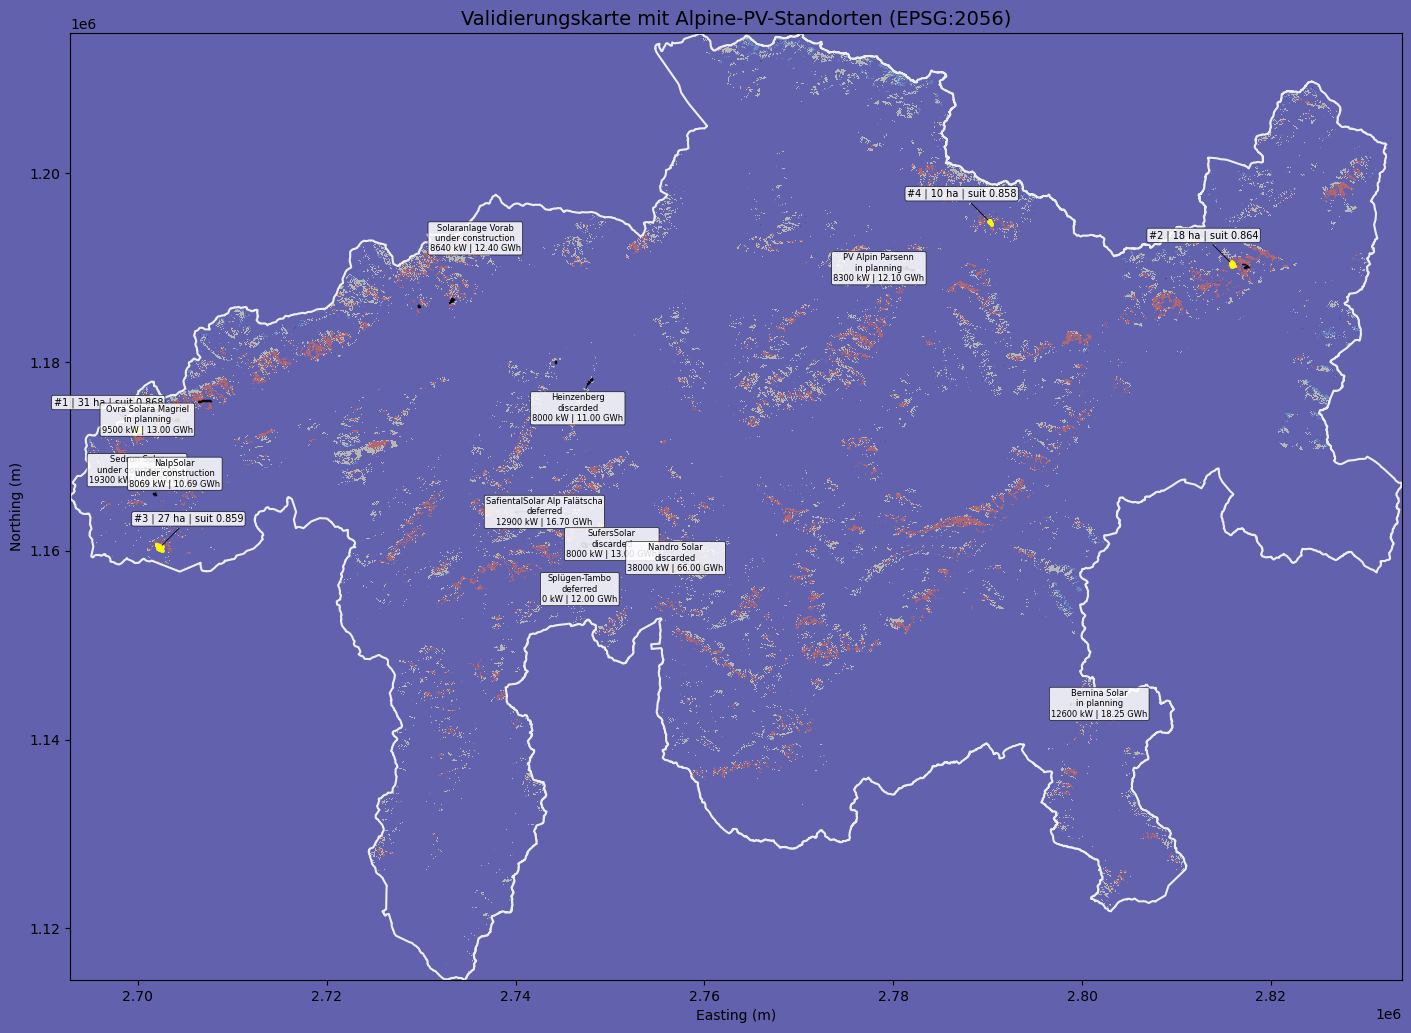

In [22]:
from pathlib import Path
if 'RAW' not in globals():
    RAW = Path('../data/raw')
if 'PROC' not in globals():
    PROC = Path('../data/processed')
if 'OUT_R' not in globals():
    OUT_R = Path('../outputs')
if 'OUT_F' not in globals():
    OUT_F = OUT_R / 'figures'
if 'OUT_T' not in globals():
    OUT_T = OUT_R / 'tables'
if 'CRS' not in globals():
    CRS = 'EPSG:2056'
if 'BG_COLOR' not in globals():
    BG_COLOR = '#6161AD'

def _bootstrap_validation_dependencies():
    import json as _json
    import re as _re

    if 'np' not in globals():
        import numpy as np
        globals()['np'] = np
    if 'pd' not in globals():
        import pandas as pd
        globals()['pd'] = pd
    if 'gpd' not in globals():
        import geopandas as gpd
        globals()['gpd'] = gpd
    if 'rasterio' not in globals():
        import rasterio
        globals()['rasterio'] = rasterio
    if 'shapes' not in globals():
        from rasterio.features import shapes
        globals()['shapes'] = shapes
    if 'shape' not in globals():
        from shapely.geometry import shape
        globals()['shape'] = shape
    if 'mcolors' not in globals():
        import matplotlib.colors as mcolors
        globals()['mcolors'] = mcolors

    if 'suit' not in globals():
        suit_path = OUT_R / 'suitability_wlc.tif'
        with rasterio.open(suit_path) as src:
            globals()['suit'] = src.read(1)
            globals()['transform'] = src.transform
            globals()['profile'] = src.profile.copy()
            globals()['height'], globals()['width'] = globals()['suit'].shape
    if 'mask' not in globals():
        with rasterio.open(PROC / 'constraints/constraint_mask_s2.tif') as src:
            globals()['mask'] = src.read(1)
    if 'valid' not in globals():
        globals()['valid'] = (globals()['suit'] > 0) & (globals()['mask'] == 1)

    if 'CLASSES' not in globals():
        _nb04_path = Path('04_wlc.ipynb')
        with open(_nb04_path, encoding='utf-8') as _f:
            _nb04_json = _json.load(_f)
        for _cell in _nb04_json['cells']:
            _src = ''.join(_cell['source'])
            if 'CLASSES = {' in _src:
                _m = _re.search(r'(CLASSES\s*=\s*\{[^}]+\})', _src, _re.DOTALL)
                if _m:
                    exec(_m.group(1), globals())
                break
        if 'CLASSES' not in globals():
            raise RuntimeError('CLASSES konnte nicht aus 04_wlc.ipynb geladen werden — Pfad prüfen')
        globals()['CLASS_COLORS'] = ['#313695', '#74add1', '#ffffbf', '#f46d43', '#a50026']
        globals()['CLASS_LABELS'] = [v[2] for v in CLASSES.values()]
        globals()['cmap_cls'] = mcolors.ListedColormap(CLASS_COLORS)
        bounds_cls = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
        globals()['norm_cls'] = mcolors.BoundaryNorm(bounds_cls, globals()['cmap_cls'].N)

    if 'suit_to_class' not in globals():
        def suit_to_class(arr, mask_2d):
            c = np.zeros(arr.shape, dtype=np.float32)
            m = mask_2d & (arr > 0)
            v = arr[m]
            cls = np.ones(v.shape)
            for cls_id, (lo, hi, _) in CLASSES.items():
                if cls_id > 1:
                    cls[v >= lo] = cls_id
            c[m] = cls
            return np.where(m, c, np.nan)
        globals()['suit_to_class'] = suit_to_class

    if 'gdf_plants' not in globals():
        plants_path = RAW / 'validation' / 'alpine_pv_plants.csv'
        if plants_path.suffix != '.csv':
            globals()['gdf_plants'] = gpd.read_file(plants_path)
        else:
            df_plants = pd.read_csv(plants_path)
            globals()['gdf_plants'] = gpd.GeoDataFrame(
                df_plants,
                geometry=gpd.points_from_xy(df_plants['lon'], df_plants['lat']),
                crs='EPSG:4326'
            ).to_crs(CRS)

_bootstrap_validation_dependencies()

val_path = RAW / 'validation' / 'validation_epsg_2056.tif'
with rasterio.open(val_path) as src:
    val_rast = src.read(1)
    val_transform = src.transform
    val_bounds = src.bounds

val_mask = val_rast > 0
val_polygons = [shape(geom) for geom, v in shapes(val_mask.astype(np.uint8), mask=val_mask, transform=val_transform)]
if val_polygons:
    gdf_val = gpd.GeoDataFrame(geometry=val_polygons, crs=CRS)
    gdf_val = gdf_val.explode(index_parts=False).reset_index(drop=True)
    gdf_val['poly_id'] = gdf_val.index + 1
else:
    gdf_val = gpd.GeoDataFrame(columns=['geometry'], geometry=[], crs=CRS)

# Join plant attributes to validation polygons by location
if not gdf_val.empty and not gdf_plants.empty:
    gdf_plants_pts = gdf_plants.set_geometry('geometry')
    gdf_joined = gpd.sjoin(gdf_plants_pts, gdf_val, how='left', predicate='within')
    if 'poly_id' in gdf_joined:
        agg = gdf_joined.groupby('poly_id').agg({
            'name': 'first',
            'capacity_kw': 'first',
            'annual_yield_gwh': 'first',
            'specific_yield_kwh_kwp': 'first',
            'status': 'first',
            'source': 'first'
        })
        gdf_val = gdf_val.merge(agg, left_on='poly_id', right_index=True, how='left')
    else:
        for col in ['name', 'capacity_kw', 'annual_yield_gwh', 'specific_yield_kwh_kwp', 'status', 'source']:
            gdf_val[col] = np.nan
else:
    for col in ['name', 'capacity_kw', 'annual_yield_gwh', 'specific_yield_kwh_kwp', 'status', 'source']:
        gdf_val[col] = np.nan

# Pflanzenpunkte nach Status färben
status_colors = {
    'connected to grid': '#1b9e77',
    'under construction': '#d95f02',
    'in planning': '#7570b3',
    'discarded': '#666666'
}

# Graubünden-Grenze laden und als Zoom-Extent verwenden
gr_border = gpd.read_file(RAW / 'swissboundaries/graubuenden_kantonsgrenze.shp').to_crs(CRS)
gr_bounds = gr_border.total_bounds

fig, ax = plt.subplots(figsize=(14, 12), constrained_layout=True, facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

def _plot_label_outside(ax, geom, text, fontsize=7, placed=None, min_sep=9000,
                        xlims=None, ylims=None):
    import math

    pt = geom.representative_point()
    px_map, py_map = pt.x, pt.y
    best_x, best_y = None, None

    for radius in [10000, 15000, 22000, 30000, 40000, 55000]:
        for step in range(32):
            angle = step * (2 * math.pi / 32)
            tx = px_map + math.cos(angle) * radius
            ty = py_map + math.sin(angle) * radius
            if xlims and not (xlims[0] < tx < xlims[1]):
                continue
            if ylims and not (ylims[0] < ty < ylims[1]):
                continue
            if placed is None or all(math.hypot(tx - ox, ty - oy) >= min_sep
                                     for ox, oy in placed):
                best_x, best_y = tx, ty
                break
        if best_x is not None:
            break

    if best_x is None:
        best_x = px_map + 10000
        best_y = py_map + 10000

    if placed is not None:
        placed.append((best_x, best_y))

    ax.annotate(
        text,
        xy=(px_map, py_map), xytext=(best_x, best_y),
        fontsize=fontsize, ha='center', va='center',
        color='black',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85, lw=0.5),
        arrowprops=dict(arrowstyle='-', color='black', lw=0.6)
    )

cls_wlc = suit_to_class(suit, valid)
extent = (transform.c, transform.c + width * transform.a,
          transform.f + height * transform.e, transform.f)
ax.imshow(cls_wlc, cmap=cmap_cls, norm=norm_cls, alpha=0.55,
          extent=extent, origin='upper', aspect='equal', interpolation='nearest')

# Graubünden-Umriss einblenden
gr_border.boundary.plot(ax=ax, color='white', linewidth=1.5, alpha=0.9)

if not gdf_val.empty:
    gdf_val.boundary.plot(ax=ax, color='black', linewidth=1.0, alpha=0.85)
    gdf_val.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0, alpha=0.5)
else:
    for status, color in status_colors.items():
        subset = gdf_plants[gdf_plants['status'] == status]
        if not subset.empty:
            subset.plot(ax=ax, markersize=45, color=color, alpha=0.9, edgecolor='black', linewidth=0.3)

placed_labels = []
xlims = (gr_bounds[0], gr_bounds[2])
ylims = (gr_bounds[1], gr_bounds[3])

if 'gdf_sites' in dir() and not gdf_sites.empty:
    top4 = gdf_sites.nlargest(4, 'mean_suit')
    top4.boundary.plot(ax=ax, edgecolor='yellow', linewidth=2.0, alpha=0.95)
    for _, row in top4.iterrows():
        label_text = f"#{row['rang']} | {row['area_ha']:.0f} ha | suit {row['mean_suit']:.3f}"
        _plot_label_outside(ax, row.geometry, label_text, fontsize=7,
                            placed=placed_labels, xlims=xlims, ylims=ylims)

# Label polygons mit plant info, wenn verfügbar
for _, row in gdf_val.dropna(subset=['name']).iterrows():
    status_text = row.get('status', None)
    label_text = f"{row['name']}"
    if pd.notna(status_text):
        label_text += f"\n{status_text}"
    label_text += f"\n{row['capacity_kw']:.0f} kW | {row['annual_yield_gwh']:.2f} GWh"
    _plot_label_outside(ax, row.geometry, label_text, fontsize=6,
                        placed=placed_labels, xlims=xlims, ylims=ylims)

ax.set_title('Validierungskarte mit Alpine-PV-Standorten (EPSG:2056)', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

ax.set_xlim(gr_bounds[0], gr_bounds[2])
ax.set_ylim(gr_bounds[1], gr_bounds[3])
ax.set_aspect('equal')

fig.savefig(OUT_F / 'validation_plants_map.png', dpi=300, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()


## Ergebnis

Alle Standorte erfüllen:
- ✓ Zusammenhängende Fläche ≥ 10 ha (Swissolar 2025)
- ✓ Geschätzte Jahresproduktion ≥ 10 GWh (Art. 71a Abs. 2 EnG)
- ✓ Geschätzte Winterproduktion ≥ 500 kWh/kW (Art. 71a Abs. 2 EnG)

**Outputs:**
- `suitability_postprocessed.tif` — Gefilterte Eignungskarte
- `top_sites.gpkg` — Standort-Polygone (für QGIS / Detail-Notebook 05)
- `postprocessing_stats.csv` — Tabelle aller Standorte

**→ Weiter mit:** `05_detail_swissalti3d.ipynb` (Micro-Siting) oder `06_validation.ipynb` (ROC/AUC + OAT)